In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [5]:
df = pd.read_csv('D:\AI&ML\Supervised Learning\Supervised Learning Task\Supervised-Learning\Exam 1\RealEstate Dataset.csv')

In [6]:
# Independent variables (features)
X = df[['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years','distance_city_km','lot_size_sqft','has_garage','has_pool','renovation_years_ago']]

# Dependent variable (target)
y = df['house_price_inr']

print("Independent Variables (X):")
print(X.head())

print("\nDependent Variable (y):")
print(y.head())

Independent Variables (X):
   area_sqft  bedrooms  bathrooms  location_score  age_years  \
0       1973         5          4             7.6         23   
1       1560         3          3             6.3         13   
2       2071         4          3             5.8          9   
3       2640         5          3             7.7         12   
4       1498         3          3             3.8         15   

   distance_city_km  lot_size_sqft  has_garage  has_pool  renovation_years_ago  
0              11.9           5220           1         0                     0  
1              15.8           3882           1         0                    13  
2              21.1           4488           0         0                     9  
3               7.9           3614           1         1                     4  
4              24.0           2663           0         0                    15  

Dependent Variable (y):
0    40275084
1    26812029
2    29315677
3    47712959
4    17724566
Name: h

In [7]:
X = df[['area_sqft']]
y = df['house_price_inr']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

In [10]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

y_pred_poly = poly_model.predict(X_test_poly)

In [11]:
print("Linear Regression R2 Score:", r2_score(y_test, y_pred_linear))

print("Polynomial Regression R2 Score:", r2_score(y_test, y_pred_poly))

Linear Regression R2 Score: 0.5625199587991578
Polynomial Regression R2 Score: 0.5626917978136475


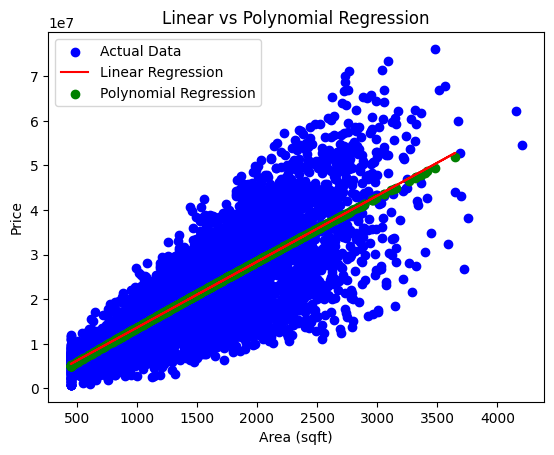

In [12]:
plt.scatter(X, y, color='blue', label="Actual Data")

# Linear line
plt.plot(X_test, y_pred_linear, color='red', label="Linear Regression")

# Polynomial curve
plt.scatter(X_test, y_pred_poly, color='green', label="Polynomial Regression")

plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.title("Linear vs Polynomial Regression")

plt.legend()
plt.show()

In [13]:
# Polynomial transformation
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

# Train model
model = LinearRegression()
model.fit(X_poly, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
area_sqft = float(input("Enter House Area (sqft): "))

# Convert input into polynomial features
input_data = poly.transform([[area_sqft]])

# Predict price
predicted_price = model.predict(input_data)

print(f"Predicted House Price: ₹{predicted_price[0]:,.2f}")

Predicted House Price: ₹44,875,736.03


C:\Users\lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


: 